# Lab 2 — DCGAN Training trên CIFAR-10 Subset

> **Mục tiêu:** Huấn luyện DCGAN trên CIFAR-10 subset (cat, dog, bird) với 500 epochs,
đánh giá FID/IS, interpolation, và phân tích phát hiện fake data.

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.decomposition import PCA
import torch
import clip
import warnings
import time
warnings.filterwarnings("ignore")
from PIL import Image
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
import pickle
import urllib.request
import tarfile
plt.style.use('default')

# TensorFlow GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"\nTensorFlow GPU available: {len(gpus) > 0}")
if gpus:
    for gpu in gpus:
        print(f"  - {gpu}")
    # Allocate GPU memory as needed (not all at once)
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU detected. Run setup guide: SETUP_UBUNTU.md")

# PyTorch GPU
print(f"\nPyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  - GPU: {torch.cuda.get_device_name(0)}")
    print(f"  - CUDA: {torch.version.cuda}")
else:
    print("No CUDA detected. Run setup guide: SETUP_UBUNTU.md")

I0000 00:00:1777991925.402112    2655 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777991926.992190    2655 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777991974.390558    2655 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



TensorFlow GPU available: True
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

PyTorch CUDA available: True
  - GPU: NVIDIA GeForce RTX 4060 Laptop GPU
  - CUDA: 13.0


# 2. Dataset CIFAR-10 Subset

## 2.1 CIFAR-10 là gì?
CIFAR-10 là một dataset bao gồm 60,000 ảnh màu kích thước $32 \times 32$ RGB thuộc 10 classes. Trong bài lab này, chúng ta chỉ sử dụng một subset gồm 3 classes (bird=2, cat=3, dog=5).
Việc này giúp giảm thời gian train (từ 50,000 ảnh xuống còn 15,000 ảnh cho tập training và 3,000 ảnh cho tập test) nhưng vẫn giữ được độ phức tạp cần thiết (ảnh có màu, nhiều objects) để đánh giá mô hình DCGAN.

## 2.2 Tải & Chuẩn bị dữ liệu

Dataset CIFAR-10 được phân phối dưới dạng Python pickle serialization format, accessible thông qua kho dữ liệu chính thức tại đường dẫn https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz. File nén có kích thước xấp xỉ 163 MB và được tổ chức thành 5 training batches độc lập cùng 1 test batch, trong đó mỗi batch được lưu trữ dưới dạng pickle object. Cấu trúc phân chia này cho phép quá trình tải dữ liệu diễn ra một cách tuần tự và hiệu quả về mặt bộ nhớ, phù hợp với quy trình tiền xử lý và huấn luyện mô hình deep learning trên tài nguyên tính toán giới hạn.

## 2.3 Quy trình xử lí dữ liệu

1. Download tar.gz (nếu chưa có)
2. Extract → ./Data/cifar-10-batches-py/
3. Load 5 training batches + 1 test batch từ pickle files
4. Reshape: (N, 3072) → (N, 32, 32, 3) với channels last
5. Filter subset: bird=2, cat=3, dog=5
6. Save cache → cifar10_subset_pickle.npz


In [ ]:
# ============================================================
# Load CIFAR-10 Subset từ Pickle Files (bird=2, cat=3, dog=5)
# download tar.gz + extract + reshape + filter + cache
# ============================================================
# Setup directories
data_dir = Path('./Data')
data_dir.mkdir(parents=True, exist_ok=True)
pickle_dir = data_dir / 'cifar-10-batches-py'
data_cache_file = data_dir / 'cifar10_subset_pickle.npz'

# Pickle file URL
CIFAR_URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
CIFAR_TAR = data_dir / 'cifar-10-python.tar.gz'

# Target labels: bird=2, cat=3, dog=5
TARGET_LABELS = [2, 3, 5]

# ============================================================
# Step 1: Download tar.gz nếu chưa có
# ============================================================
if not pickle_dir.exists():
    print(f"Pickle directory not found: {pickle_dir}")
    print(f"Downloading CIFAR-10 from {CIFAR_URL}...")
    
    if not CIFAR_TAR.exists():
        try:
            urllib.request.urlretrieve(CIFAR_URL, CIFAR_TAR)
            print(f"Downloaded: {CIFAR_TAR}")
        except Exception as e:
            print(f"Download failed: {e}")
            raise
    
    # Extract tar.gz
    print(f"Extracting {CIFAR_TAR}...")
    try:
        with tarfile.open(CIFAR_TAR, 'r:gz') as tar:
            tar.extractall(path=data_dir)
        print(f"✓ Extracted to: {data_dir}")
        
        # Cleanup tar.gz
        CIFAR_TAR.unlink()
        print(f"✓ Cleaned up tar.gz")
    except Exception as e:
        print(f"✗ Extraction failed: {e}")
        raise

# ============================================================
# Step 2: Load từ cache nếu tồn tại
# ============================================================
if data_cache_file.exists():
    print(f"\nLoading cached CIFAR-10 subset from {data_cache_file}")
    cached = np.load(data_cache_file)
    x_train = cached['x_train']
    y_train = cached['y_train']
    x_test = cached['x_test']
    y_test = cached['y_test']
    print(f"  x_train: {x_train.shape}, y_train: {y_train.shape}")
    print(f"  x_test: {x_test.shape}, y_test: {y_test.shape}")

else:
    print(f"\nPickle directory found: {pickle_dir}")
    print("Loading CIFAR-10 from pickle files...")
    
    def unpickle(file):
        with open(file, 'rb') as fo:
            dict_obj = pickle.load(fo, encoding='bytes')
        return dict_obj
    
    # ============================================================
    # Step 3: Load 5 training batches + 1 test batch
    # ============================================================
    print("\nLoading training batches...")
    x_train_list = []
    y_train_list = []
    
    for i in range(1, 6):
        batch_file = pickle_dir / f'data_batch_{i}'
        if not batch_file.exists():
            raise FileNotFoundError(f"Missing batch file: {batch_file}")
        
        print(f"  Loading {batch_file.name}...")
        batch_dict = unpickle(batch_file)
        
        # Keys: b'batch_label', b'labels', b'data', b'filenames'
        x_train_list.append(batch_dict[b'data'])
        y_train_list.append(batch_dict[b'labels'])
    
    # Combine all training batches
    x_train_full = np.concatenate(x_train_list, axis=0)  # (50000, 3072)
    y_train_full = np.concatenate(y_train_list, axis=0)  # (50000,)
    
    # Load test batch
    print("Loading test batch...")
    test_batch_file = pickle_dir / 'test_batch'
    if not test_batch_file.exists():
        raise FileNotFoundError(f"Missing test batch file: {test_batch_file}")
    
    test_dict = unpickle(test_batch_file)
    x_test_full = test_dict[b'data']      # (10000, 3072)
    y_test_full = test_dict[b'labels']    # (10000,)
    
    # ============================================================
    # Step 4: Reshape từ (N, 3072) → (N, 32, 32, 3)
    # Pickle format: [R_1, R_2, ..., R_1024, G_1, ..., G_1024, B_1, ..., B_1024]
    # ============================================================
    print("\nReshaping from (N, 3072) to (N, 32, 32, 3)...")
    x_train_full = x_train_full.reshape(-1, 3, 32, 32)  # (50000, 3, 32, 32)
    x_train_full = np.transpose(x_train_full, (0, 2, 3, 1))  # (50000, 32, 32, 3) - channels last
    
    x_test_full = x_test_full.reshape(-1, 3, 32, 32)    # (10000, 3, 32, 32)
    x_test_full = np.transpose(x_test_full, (0, 2, 3, 1))   # (10000, 32, 32, 3)
    
    # ============================================================
    # Step 5: Filter subset - giữ lại chỉ bird(2), cat(3), dog(5)
    # ============================================================
    print(f"\nFiltering subset: labels {TARGET_LABELS}...")
    train_mask = np.isin(y_train_full, TARGET_LABELS)
    test_mask = np.isin(y_test_full, TARGET_LABELS)
    
    x_train = x_train_full[train_mask]
    y_train = np.array(y_train_full)[train_mask]
    x_test = x_test_full[test_mask]
    y_test = np.array(y_test_full)[test_mask]
    
    print(f"  x_train: {x_train.shape} (from {x_train_full.shape})")
    print(f"  y_train: {y_train.shape}, labels: {np.unique(y_train)}")
    print(f"  x_test: {x_test.shape} (from {x_test_full.shape})")
    print(f"  y_test: {y_test.shape}, labels: {np.unique(y_test)}")
    
    # Convert to uint8
    x_train = x_train.astype(np.uint8)
    x_test = x_test.astype(np.uint8)
    y_train = y_train.astype(np.int32)
    y_test = y_test.astype(np.int32)
    
    # ============================================================
    # Step 6: Save to cache
    # ============================================================
    print(f"\nSaving subset to cache: {data_cache_file}")
    np.savez(data_cache_file, 
             x_train=x_train, y_train=y_train,
             x_test=x_test, y_test=y_test)
    print("Cache saved!")

# ============================================================
# Normalize: [0,255] → [-1,1]
# ============================================================
x_train = (x_train.astype('float32') - 127.5) / 127.5
x_test  = (x_test.astype('float32')  - 127.5) / 127.5

BUFFER_SIZE = x_train.shape[0]
BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices(x_train) \
    .shuffle(BUFFER_SIZE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

# Class labels for visualization
CLASS_NAMES = {2: 'bird', 3: 'cat', 5: 'dog'}
CLASS_LABELS = ['bird', 'cat', 'dog']

print(f"\n{'='*60}")
print(f"CIFAR-10 Pickle Subset loaded successfully!")
print(f"{'='*60}")
print(f"Training set: {x_train.shape[0]} images, shape {x_train.shape[1:]}")
print(f"Test set:     {x_test.shape[0]} images, shape {x_test.shape[1:]}")
print(f"Classes: {CLASS_LABELS}")
print(f"Pixel range (normalized): [{x_train.min():.2f}, {x_train.max():.2f}]")
print(f"Cache file: {data_cache_file}")
print(f"{'='*60}")


Loading cached CIFAR-10 subset from Data/cifar10_subset_pickle.npz
  x_train: (15000, 32, 32, 3), y_train: (15000,)
  x_test: (3000, 32, 32, 3), y_test: (3000,)

CIFAR-10 Pickle Subset loaded successfully!
Training set: 15000 images, shape (32, 32, 3)
Test set:     3000 images, shape (32, 32, 3)
Classes: ['bird', 'cat', 'dog']
Pixel range (normalized): [-1.00, 1.00]
Cache file: Data/cifar10_subset_pickle.npz


# 3. Kiến trúc DCGAN

## 3.1 Generator

### Input → Output
- **Input:** $z \in \mathbb{R}^{100} \sim \mathcal{N}(0,I)$ — latent noise vector
- **Output:** $G(z) \in \mathbb{R}^{32 \times 32 \times 3}$ — RGB image trong $[-1, 1]$

### 3.1.1 Data Flow từng layer:

| Layer | Input Shape | Operation | Output Shape |
|-------|-------------|-----------|--------------|
| **1. Dense Projection** | (batch, 100) | Dense(4,096) → BatchNorm → LeakyReLU(0.2) → Reshape | (batch, 4, 4, 256) |
| **2. Deconv 1** | (batch, 4, 4, 256) | Conv2DTranspose(128, k=5, s=2) → BatchNorm → LeakyReLU(0.2) | (batch, 8, 8, 128) |
| **3. Deconv 2** | (batch, 8, 8, 128) | Conv2DTranspose(64, k=5, s=2) → BatchNorm → LeakyReLU(0.2) | (batch, 16, 16, 64) |
| **4. Deconv 3 (Final)** | (batch, 16, 16, 64) | Conv2DTranspose(3, k=5, s=2) → **tanh** ([-1,1]) | (batch, 32, 32, 3) |

**Total params:** ~2.4M trainable

### 3.1.2 Lựa chọn Activation Function: LeakyReLU vs ReLU

Activation function ReLU tiêu chuẩn định nghĩa gradient bằng 0 cho tất cả các input âm, dẫn đến hiện tượng "dying ReLU" (dead neurons) trong quá trình huấn luyện. Cụ thể, khi một neuron đạt trạng thái activation âm, gradient được truyền ngược bằng 0, làm cho các trọng số liên kết không được cập nhật. Sau nhiều iterations, một số lượng đáng kể các neurons trở nên không hoạt động và không thể khôi phục, gây ra suy giảm hiệu năng mô hình. Để giải quyết vấn đề này, hàm LeakyReLU được đề xuất nhằm duy trì gradient flow bằng cách cho phép một thành phần tuyến tính nhỏ xuyên qua với các input âm, thay vì hoàn toàn chặn chúng. Với hệ số rò rỉ $\alpha = 0.2$, hàm được định nghĩa như sau:
$$\text{LeakyReLU}_\alpha(x) = \begin{cases} x & \text{if } x \geq 0 \\ \alpha x & \text{if } x < 0 \end{cases}, \quad \alpha = 0.2$$
Cơ chế này đảm bảo rằng gradient luôn khác 0, cho phép các weights tiếp tục được cập nhật ngay cả khi input âm, từ đó cải thiện khả năng biểu diễn và ổn định huấn luyện của mô hình sinh.

### 3.1.3 Lựa chọn Output Activation: Tanh vs Sigmoid

Lựa chọn activation function output layer là tối quan trọng vì nó quyết định output range của Generator. Trong DCGAN, chúng ta normalize input data từ [0, 255] thành [-1, 1]. Điều này không phải lựa chọn ngẫu nhiên mà là sự khớp lệ hoàn hảo với hàm tanh.

Nếu dùng sigmoid với output range [0, 1], Generator sẽ không khớp với data range [-1, 1]. Để khắc phục điều này, Generator phải học thêm một phép biến đổi (**transformation**) để điều chỉnh output từ [0, 1] về [-1, 1]. Quá trình này làm training phức tạp hơn, chậm hơn, và khó hội tụ.

Ngược lại, tanh có output range chính xác [-1, 1], khớp hoàn toàn với data range. Điều này cho phép training diễn ra trơn tru hơn mà không cần phép biến đổi thêm. Ngoài ra, tanh còn có ưu điểm gradient học tập. Tại điểm x=0, gradient của tanh là 1.0 trong khi sigmoid chỉ là 0.25, giúp quá trình backpropagation hiệu quả hơn và learning nhanh hơn.

$$\text{Sigmoid}(x) = \frac{1}{1 + e^{-x}} \in [0, 1], \quad \frac{d}{dx}\text{Sigmoid}(x) = \text{Sigmoid}(x)(1-\text{Sigmoid}(x)) \approx 0.25 \text{ at } x=0$$

$$\text{tanh}(x) = \frac{e^{2x} - 1}{e^{2x} + 1} \in [-1, 1], \quad \frac{d}{dx}\text{tanh}(x) = 1 - \text{tanh}^2(x) = 1.0 \text{ at } x=0$$

Tổng quát, một quy tắc thiết kế hiệu quả là: **activation output range phải khớp với data range**. Khi data nằm trong [-1, 1], ta dùng tanh; khi data trong [0, 1], ta dùng sigmoid; khi data không bị giới hạn, ta dùng ReLU hoặc Linear.

In [ ]:
# ============================================================
# DCGAN Generator — TensorFlow Keras
# input: z (batch, 100) → output: (batch, 32, 32, 3), range [-1, 1]
# ============================================================
def make_dcgan_generator(z_dim=100):
    model = keras.Sequential(name='DCGAN_Generator')

    # Layer 1: z → 4×4×256
    model.add(layers.Dense(4 * 4 * 256, use_bias=False, input_shape=(z_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Reshape((4, 4, 256)))

    # Layer 2: 4×4 → 8×8
    model.add(layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))

    # Layer 3: 8×8 → 16×16
    model.add(layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))

    # Layer 4: 16×16 → 32×32 (output)
    model.add(layers.Conv2DTranspose(3, 5, strides=2, padding='same',
                                    activation='tanh'))

    return model

dcgan_gen = make_dcgan_generator()
dcgan_gen.summary()

Model: "DCGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │       409,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │         4,803 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,455,555 (5.55 MB)

 Trainable params: 1,446,979 (5.52 MB)

 Non-trainable params: 8,576 (33.50 KB)

## 3.2 Discriminator

### Input → Output
- **Input:** $x \in \mathbb{R}^{32 \times 32 \times 3}$ — RGB image trong $[-1, 1]$
- **Output:** $D(x) \in [0, 1]$ — xác suất real (1) hay fake (0)

### 3.2.1 Data Flow từng layer:

| Layer | Input Shape | Operation | Output Shape |
|-------|-------------|-----------|--------------|
| **1. Conv 1** | (batch, 32, 32, 3) | Conv2D(64, k=5, s=2) → LeakyReLU(0.2) → Dropout(0.3) | (batch, 16, 16, 64) |
| **2. Conv 2** | (batch, 16, 16, 64) | Conv2D(128, k=5, s=2) → LeakyReLU(0.2) → Dropout(0.3) | (batch, 8, 8, 128) |
| **3. Conv 3** | (batch, 8, 8, 128) | Conv2D(256, k=5, s=2) → LeakyReLU(0.2) → Dropout(0.3) | (batch, 4, 4, 256) |
| **4. Output** | (batch, 4, 4, 256) | Flatten → Dense(1) → **sigmoid** [0,1] | (batch, 1) |

**Total params:** ~2.8M trainable

### 3.2.2 Tại sao dùng Dropout?
Dropout trong Discriminator = **regularization**, giảm overfitting.

Discriminator nhìn cả real và fake → dễ overfit hơn Generator.

Dropout chỉ dùng khi training (không dùng trong inference).

$$\text{Dropout}_p: y = x \cdot \frac{\text{Bernoulli}(1-p)}{1-p}$$

### 3.2.3 Tại sao strides=2 thay vì pooling?
Strides=2 vừa giảm spatial size vừa tăng receptive field → hiệu quả hơn max-pooling.

Tính receptive field: $RF = 1 + 2(k-1) \cdot s$, với $k$ = kernel size, $s$ = stride

In [7]:
# ============================================================
# DCGAN Discriminator — TensorFlow Keras
# input: (batch, 32, 32, 3) → output: (batch, 1), sigmoid probability
# ============================================================
def make_dcgan_discriminator():
    model = keras.Sequential(name='DCGAN_Discriminator')

    # Layer 1: 32×32 → 16×16
    model.add(layers.Conv2D(64, 5, strides=2, padding='same',
                            input_shape=(32, 32, 3)))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # Layer 2: 16×16 → 8×8
    model.add(layers.Conv2D(128, 5, strides=2, padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # Layer 3: 8×8 → 4×4
    model.add(layers.Conv2D(256, 5, strides=2, padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # Output
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

dcgan_disc = make_dcgan_discriminator()
dcgan_disc.summary()

Model: "DCGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,033,345 (3.94 MB)

 Trainable params: 1,033,345 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Quá trình training DCGAN

## 4.1 Loss Function

### Discriminator Loss:
$$\mathcal{L}_D = -\left[\log D(x) + \log(1 - D(G(z)))\right]$$

→ D muốn: $D(\text{real}) \to 1$, $D(G(z)) \to 0$

→ Minimize $\mathcal{L}_D$: maximize $\log D(\text{real})$ + maximize $\log(1 - D(G(z)))$

### Generator Loss:
$$\mathcal{L}_G = -\log D(G(z))$$

→ G muốn: $D(G(z)) \to 1$ (fool D)

→ Minimize $\mathcal{L}_G$: maximize $\log D(G(z))$ tương đương minimize $-\log D(G(z))$

### Binary Cross-Entropy:
$$\text{BCE}(y, \hat{y}) = -\left[y \log \hat{y} + (1-y) \log(1-\hat{y})\right]$$

## 4.2 Training Step

```
For each batch:
  1. Sample z ~ N(0,1)
  2. Sample real_images from dataset
  3. D step:
     - fake_images = G(z)
     - real_output = D(real_images)
     - fake_output = D(fake_images)
     - d_loss = BCE(real=1) + BCE(fake=0)
     - d_gradients = gradient(d_loss, D.trainable_variables)
     - d_optimizer.apply_gradients(d_gradients)

  4. G step (sau D step):
     - z_new = N(0,1)
     - fake_images = G(z_new)
     - g_loss = BCE(fake_output, labels=1)
     - g_gradients = gradient(g_loss, G.trainable_variables)
     - g_optimizer.apply_gradients(g_gradients)
```

## 4.3 Tại sao train D trước G?
G training cần gradient từ D. Nếu train G trước, D chưa được update

→ gradient không meaningful. Train D → rồi train G → đảm bảo

G nhận được meaningful signal.

## 4.4 Tối ưu hóa: Adam(lr=2e-4, beta1=0.5)
$$\theta_t = \theta_{t-1} - \alpha \frac{m_t}{\sqrt{v_t} + \epsilon}$$

- $m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$ (1st moment)
- $v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$ (2nd moment)

lr=2e-4 (thay vì 1e-3) → stable training hơn.

beta1=0.5 (thay vì 0.9) → momentum phù hợp cho GAN (theo DCGAN paper gốc).

Training DCGAN...


E0000 00:00:1777475934.579134   92255 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDCGAN_Discriminator_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1777475934.866807  103291 cuda_dnn.cc:461] Loaded cuDNN version 92101


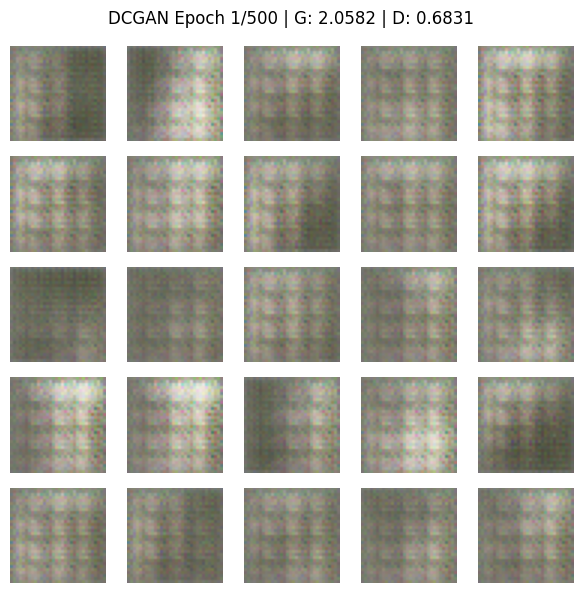

Epoch   1/500 | G: 2.0582 | D: 0.6831 | 11s


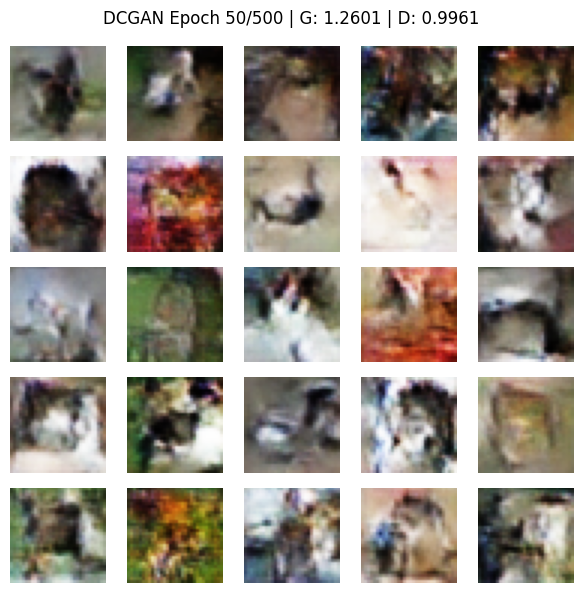

Epoch  50/500 | G: 1.2601 | D: 0.9961 | 194s


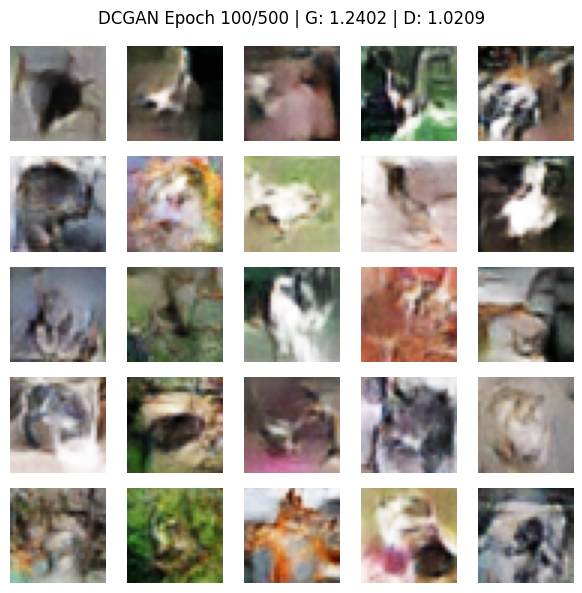

Epoch 100/500 | G: 1.2402 | D: 1.0209 | 385s


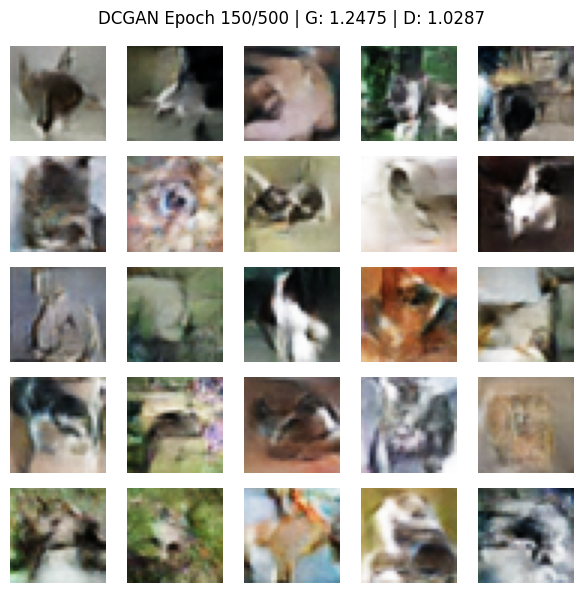

Epoch 150/500 | G: 1.2475 | D: 1.0287 | 574s


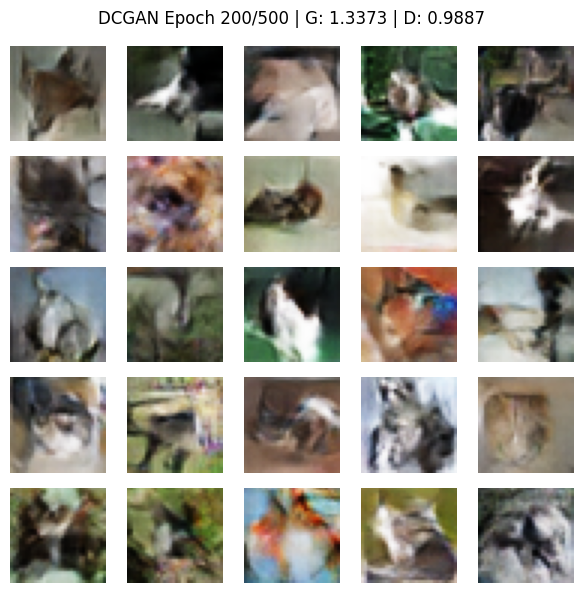

Epoch 200/500 | G: 1.3373 | D: 0.9887 | 774s


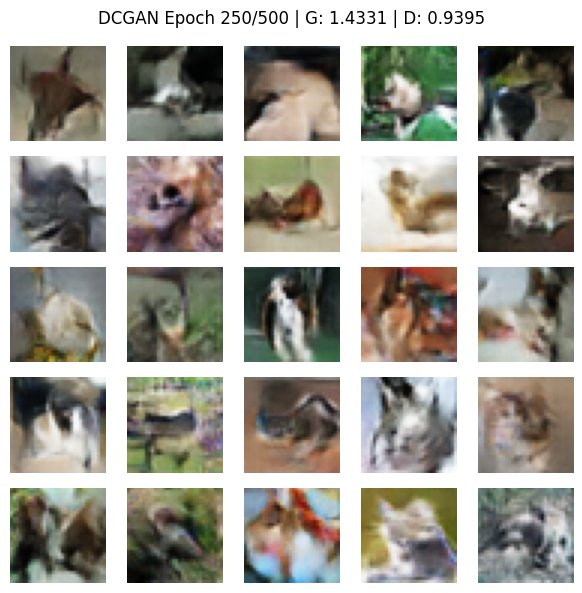

Epoch 250/500 | G: 1.4331 | D: 0.9395 | 972s


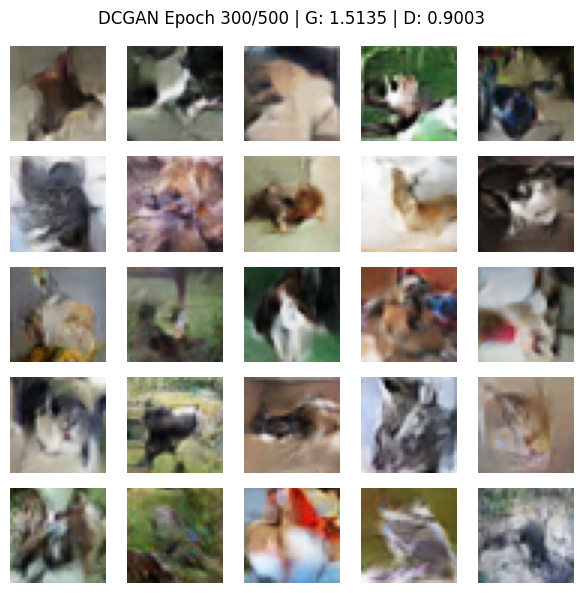

Epoch 300/500 | G: 1.5135 | D: 0.9003 | 1177s


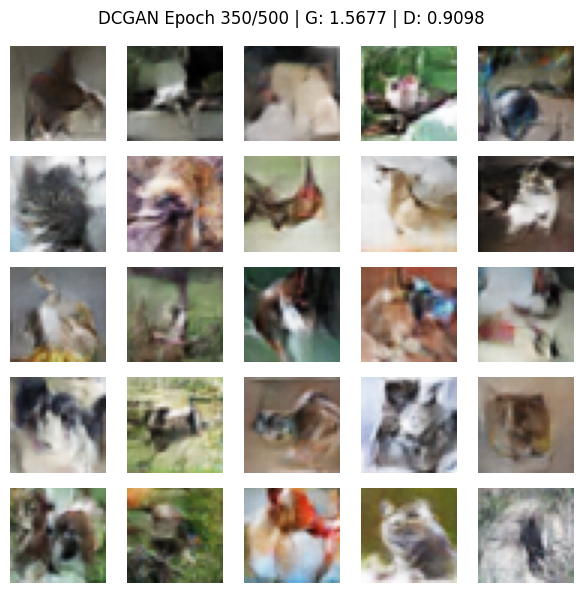

Epoch 350/500 | G: 1.5677 | D: 0.9098 | 1378s


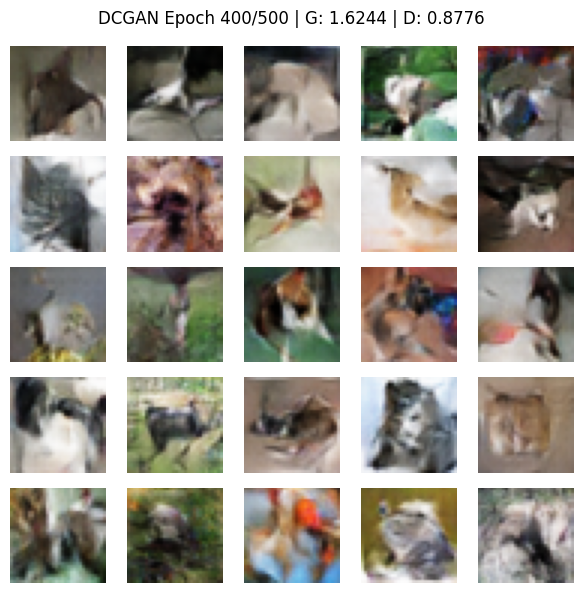

Epoch 400/500 | G: 1.6244 | D: 0.8776 | 1577s


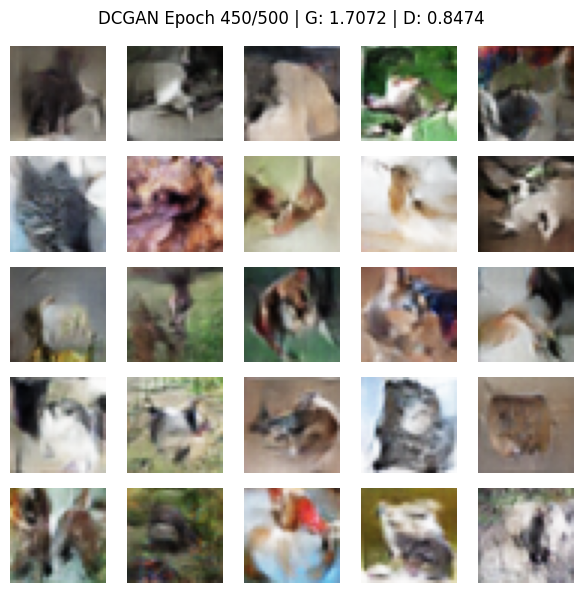

Epoch 450/500 | G: 1.7072 | D: 0.8474 | 1768s


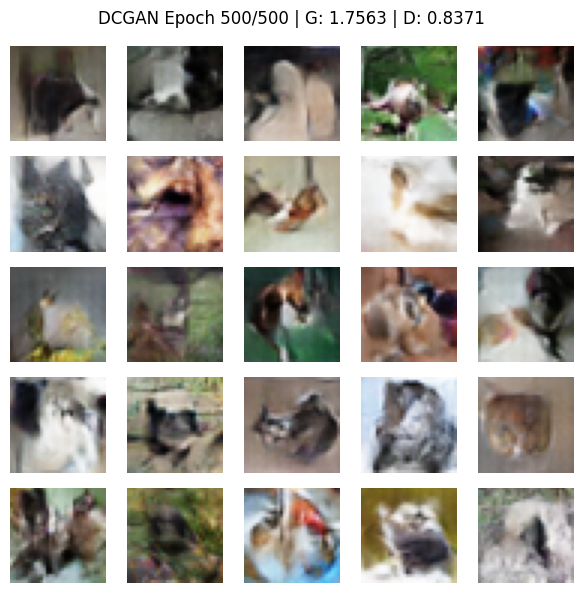

Epoch 500/500 | G: 1.7563 | D: 0.8371 | 1952s

DCGAN done in 1952s


In [8]:
# ============================================================
# DCGAN Training — 500 epochs
# ============================================================
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=False)

dcgan_gen_opt  = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
dcgan_disc_opt = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

EPOCHS   = 500
Z_DIM    = 100
SEED     = tf.random.normal([25, Z_DIM])

@tf.function
def dcgan_train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    z = tf.random.normal([batch_size, Z_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = dcgan_gen(z, training=True)
        real_out = dcgan_disc(real_images, training=True)
        fake_out = dcgan_disc(fake_images, training=True)

        gen_loss  = cross_entropy(tf.ones_like(fake_out), fake_out)
        disc_loss = (cross_entropy(tf.ones_like(real_out), real_out) +
                    cross_entropy(tf.zeros_like(fake_out), fake_out))

    dcgan_gen_opt.apply_gradients(
        zip(gen_tape.gradient(gen_loss, dcgan_gen.trainable_variables),
            dcgan_gen.trainable_variables))
    dcgan_disc_opt.apply_gradients(
        zip(disc_tape.gradient(disc_loss, dcgan_disc.trainable_variables),
            dcgan_disc.trainable_variables))

    return gen_loss, disc_loss

# Training loop
dcgan_gen_losses  = []
dcgan_disc_losses = []


print("Training DCGAN...")
start = time.time()
for epoch in range(EPOCHS):
    ep_g, ep_d = [], []
    for img_batch in train_ds:
        g, d = dcgan_train_step(img_batch)
        ep_g.append(g.numpy())
        ep_d.append(d.numpy())

    dcgan_gen_losses.append(np.mean(ep_g))
    dcgan_disc_losses.append(np.mean(ep_d))

    if (epoch + 1) % 50 == 0 or epoch == 0:
        preds = dcgan_gen(SEED, training=False).numpy()
        preds = (preds * 127.5 + 127.5).astype(np.uint8).clip(0, 255)

        fig, axes = plt.subplots(5, 5, figsize=(6, 6))
        for i, ax in enumerate(axes.flat):
            ax.imshow(preds[i])
            ax.axis('off')
        plt.suptitle(f'DCGAN Epoch {epoch+1}/{EPOCHS} | G: {dcgan_gen_losses[-1]:.4f} | D: {dcgan_disc_losses[-1]:.4f}')
        plt.tight_layout()
        plt.show()

        elapsed = time.time() - start
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | G: {dcgan_gen_losses[-1]:.4f} | D: {dcgan_disc_losses[-1]:.4f} | {elapsed:.0f}s")

print(f"\nDCGAN done in {time.time()-start:.0f}s")

# 5. Các chỉ số đánh giá

## 5.1 FID Score (Fréchet Inception Distance)

FID giống như **đo khoảng cách giữa 2 đám mây** trong không gian feature.

Hình dung:
- Ảnh real tạo thành 1 đám mây (phân bố) trong feature space
- Ảnh fake từ GAN cũng tạo thành 1 đám mây
- FID = khoảng cách giữa 2 đám mây này

Nếu 2 đám mây gần nhau → fake giống real → FID thấp ✓
Nếu 2 đám mây xa nhau → fake khác real → FID cao ✗

#### Công thức toán học
$$\text{FID}(P_r, P_g) = \left\|\mu_r - \mu_g\right\|_2^2 + \text{Tr}\left(\Sigma_r + \Sigma_g - 2\sqrt{\Sigma_r^{1/2} \Sigma_g \Sigma_r^{1/2}}\right)$$

Trong đó:
- **$\mu_r, \mu_g$**: trung bình (center) của mỗi đám mây
  - $\mu_r$: trung bình tọa độ của ảnh real
  - $\mu_g$: trung bình tọa độ của ảnh fake
  - Phần $\|\mu_r - \mu_g\|_2^2$ = khoảng cách giữa 2 tâm
  
- **$\Sigma_r, \Sigma_g$**: ma trận hiệp phương sai (covariance matrix)
  - Đo "hình dạng" và "độ rộng" của mỗi đám mây
  - Nếu đám mây "dẹt" (ít đa dạng) → covariance nhỏ
  - Nếu đám mây "chữ U" rộng (rất đa dạng) → covariance lớn
  - Trung bình hình dạng 2 đám: $2\sqrt{\Sigma_r^{1/2} \Sigma_g \Sigma_r^{1/2}}$ (Fréchet mean)
  
- **$\text{Tr}(\cdot)$**: trace = tổng các phần tử đường chéo (đo tổng "sai khác")

#### Ý nghĩa
- **FID = 0:** real và fake giống hệt nhau (tâm trùng + hình dạng giống)
- **FID nhỏ** (< 50): tốt cho CIFAR-10
- **FID rất nhỏ** (< 10): xuất sắc (publications level)

---

## 5.2 Inception Score (IS) — Đo độ "có ý nghĩa" của ảnh
IS trả lời câu hỏi: **"Ảnh fake có được phân loại rõ ràng thành 1 class không?"**

Hình dung:
- Dùng AI classifier (Inception) để nhìn ảnh fake
- Nếu classifier chắc chắn "ảnh này là chó" → entropy thấp → tốt
- Nếu classifier "không biết ảnh này là gì" → entropy cao → xấu

IS cao = ảnh:
1. **Đặc thù class** (rõ ràng là chó hoặc mèo, không mơ hồ)
2. **Đa dạng** (có nhiều loại chó, mèo, chim)

#### Công thức toán học
$$IS = \exp\left(\mathbb{E}_{x \sim P_g}\left[D_{KL}\left(p(y|x) \big\| p(y)\right)\right]\right)$$

Giải thích từng phần:

**1. $p(y|x)$ — Xác suất class của ảnh $x$**
- Ví dụ: xem ảnh fake, classifier nói:
  - P(chó) = 0.8 (chắc chắn là chó)
  - P(mèo) = 0.1
  - P(chim) = 0.1
  - → Entropy thấp (tập trung vào 1 class)

**2. $p(y) = \mathbb{E}_{x}[p(y|x)]$ — Trung bình xác suất trên tất cả ảnh**
- Ví dụ: nhìn 1000 ảnh fake, trung bình:
  - P(chó) = 0.5 (nửa là chó)
  - P(mèo) = 0.3 (1/3 là mèo)
  - P(chim) = 0.2 (1/5 là chim)
  - → Entropy cao (cân bằng nhiều class)

**3. KL-Divergence — Khoảng cách Kullback-Leibler**
$$D_{KL}(P||Q) = \sum_{y} p(y|x) \log \frac{p(y|x)}{p(y)}$$

- IS cao khi: mỗi ảnh **peaked** (entropy $p(y|x)$ thấp) nhưng tổng thể **diverse** (entropy $p(y)$ cao)
- Ví dụ:
  - Nếu GAN chỉ sinh chó: $p(y|x)$ cao cho chó, nhưng $p(y)$ thiên về chó → IS thấp ✗
  - Nếu GAN sinh cân bằng: $p(y|x)$ peaked, $p(y)$ uniform → IS cao ✓

**Công thức KL-divergence hiểu dễ:**
$$D_{KL}(P||Q) = \sum_{y} p(y|x) \log \frac{p(y|x)}{p(y)} \approx \text{"khoảng cách từ P tới Q"}$$
- KL = 0: $P = Q$ (2 phân bố giống nhau)
- KL lớn: $P \neq Q$ (2 phân bố khác nhau)

#### Diễn giải kết quả
**IS cho các dataset:**
- MNIST (10 class, đơn giản): IS = 6-12
- CIFAR-10 (10 class, phức tạp): IS = 3-8
- ImageNet (1000 class): IS = 10-100

---

## 5.3 Tại sao dùng cả FID và IS?

| Metric | Ưu điểm | Nhược điểm |
|--------|---------|--------|
| **FID** | Phát hiện **mode collapse**, đo độ gần distribution | Chỉ số tuyệt đối (khó so sánh cross-dataset) |
| **IS** | Đo **chất lượng + đa dạng**, dễ tính | Không phát hiện mode collapse, phụ thuộc classifier |

**Ví dụ mode collapse:**
```
GAN chỉ sinh chó (mode collapse):
- FID cao (distribution khác real nhiều) ✓ phát hiện
- IS có thể vẫn cao (classifier nghĩ "ảnh đẹp là chó") ✗ không phát hiện
```

→ **Kết luận:** Dùng **cả 2 metrics** để đánh giá đầy đủ: FID phát hiện distribution mismatch, IS phát hiện chất lượng & diversity.

In [ ]:
# ============================================================
# FID + IS Evaluation
# ============================================================

N_SAMPLES = 1000
Z_DIM = 100

# Generate fake images
z_eval = tf.random.normal([N_SAMPLES, Z_DIM])

dcgan_fake_raw = dcgan_gen(z_eval, training=False).numpy() * 127.5 + 127.5
real_images_raw = (x_test[:N_SAMPLES] * 127.5 + 127.5).astype(np.float32)

print(f"Shapes -- real: {real_images_raw.shape}, dcgan: {dcgan_fake_raw.shape}")

# ============================================================
# Load InceptionV3 for FID and IS (with ./Model folder management)
# ============================================================
print("Loading InceptionV3...")

# Setup model folder
model_dir = Path('./Model')
model_dir.mkdir(parents=True, exist_ok=True)

# Path to weights file
inception_weights_path = model_dir / 'inception_v3_weights_tf_dim_ordering_tf_kernels.h5'
inception_weights_url = 'https://storage.googleapis.com/tensorflow/keras-applications/inception_v3/inception_v3_weights_tf_dim_ordering_tf_kernels.h5'

# Download weights if not exist
if not inception_weights_path.exists():
    print(f"Weights file not found: {inception_weights_path}")
    print(f"Downloading from {inception_weights_url}...")
    
    try:
        urllib.request.urlretrieve(inception_weights_url, inception_weights_path)
        print(f"Downloaded: {inception_weights_path}")
    except Exception as e:
        print(f"Download failed: {e}")
        raise
else:
    print(f"Found weights: {inception_weights_path}")

# Set Keras cache to custom directory
os.environ['KERAS_HOME'] = str(model_dir)

try:
    # Load model WITHOUT weights, then load from file
    inception = InceptionV3(weights=None, include_top=True, input_shape=(299, 299, 3))
    inception.load_weights(inception_weights_path)
    inception.trainable = False
except Exception as e:
    print(f"InceptionV3 load failed: {e}")
    raise

# Extract penultimate layer (2048-dim features) for FID
fid_model = keras.Model(inputs=inception.input,
                        outputs=inception.layers[-2].output)
fid_model.trainable = False

# ============================================================
# Resize images to 299x299 (InceptionV3 input size)
# ============================================================
def resize_batch(images):
    resized = []
    for img in images:
        img_pil = tf.image.resize(img[np.newaxis], (299, 299), method='bilinear')[0]
        resized.append(img_pil.numpy())
    return np.array(resized)

print("Resizing images to 299x299...")
dcgan_fake_resized = resize_batch(dcgan_fake_raw)
real_images_resized = resize_batch(real_images_raw)

# ============================================================
# FID: Extract InceptionV3 features (2048-dim)
# ============================================================
def extract_inception_features(images, batch_size=100):
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size].astype(np.float32)
        batch = preprocess_input(batch)  # InceptionV3 preprocessing
        feats = fid_model.predict(batch, verbose=0)
        features.append(feats)
    return np.concatenate(features, axis=0)

print("Extracting InceptionV3 features for FID...")
real_feats = extract_inception_features(real_images_resized)
dcgan_feats = extract_inception_features(dcgan_fake_resized)

def calc_fid_correct(real_feats, fake_feats):
    mu_real = np.mean(real_feats, axis=0)
    mu_fake = np.mean(fake_feats, axis=0)
    sigma_real = np.cov(real_feats.T)
    sigma_fake = np.cov(fake_feats.T)

    diff = mu_real - mu_fake
    diff_sq = np.sum(diff**2)

    # Frobenius norm of the difference between covariance matrices
    sqrt_prod = sqrtm(np.dot(sigma_real, sigma_fake)).real
    trace = np.trace(sigma_real + sigma_fake - 2*sqrt_prod)

    fid = diff_sq + trace
    return max(0.0, fid)

dcgan_fid = calc_fid_correct(real_feats, dcgan_feats)

print(f"\n=== FID Evaluation (InceptionV3 2048-dim features) ===")
print(f"DCGAN FID: {dcgan_fid:.2f}")

# ============================================================
# IS: Use InceptionV3 classifier output (1000 classes)
# ============================================================
def inception_score(images, model, batch_size=100, splits=10):
    n = len(images)
    preds = []

    for i in range(0, n, batch_size):
        batch = images[i:i+batch_size].astype(np.float32)
        batch = preprocess_input(batch)  # InceptionV3 preprocessing
        probs = model.predict(batch, verbose=0)  # (batch, 1000) class probabilities
        preds.append(probs)

    preds = np.concatenate(preds, axis=0)

    # Compute IS: exp(E[KL(p(y|x) || p(y))])
    scores = []
    for i in range(splits):
        part = preds[i*n//splits:(i+1)*n//splits]
        p_y = np.mean(part, axis=0)  # marginal class probability

        # KL divergence: sum(p * log(p/q))
        kl = part * (np.log(part + 1e-10) - np.log(p_y + 1e-10))
        kl_sum = np.sum(kl, axis=1)
        score = np.exp(np.mean(kl_sum))
        scores.append(score)

    return np.mean(scores), np.std(scores)

print("\nComputing IS...")
dcgan_is, dcgan_is_std = inception_score(dcgan_fake_resized, inception)

print(f"\n=== IS Evaluation (InceptionV3 1000 classes) ===")
print(f"DCGAN IS: {dcgan_is:.2f} +/- {dcgan_is_std:.2f}")

Shapes -- real: (1000, 32, 32, 3), dcgan: (1000, 32, 32, 3)
Loading InceptionV3...
Found weights: Model/inception_v3_weights_tf_dim_ordering_tf_kernels.h5
Model directory: Model
InceptionV3 loaded from: Model
Resizing images to 299x299...
Extracting InceptionV3 features for FID...


I0000 00:00:1777478367.331515  103294 service.cc:153] XLA service 0x5dd7556409b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777478367.333078  103294 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777478367.657830  103294 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777478384.323417  103294 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



=== FID Evaluation (InceptionV3 2048-dim features) ===
DCGAN FID: 85.45
Computing IS...

=== IS Evaluation (InceptionV3 1000 classes) ===
DCGAN IS: 4.38 +/- 0.23

=== SUMMARY ===
Model  |       FID |         IS | Final G Loss
DCGAN  |     85.45 |    4.38+/-0.23 | 1.7563


## 5.4 Trực quan hóa Real vs DCGAN

Hiển thị 2 hàng so sánh:

**Hàng 1 (Real):** 5 ảnh thực từ dataset CIFAR-10

**Hàng 2 (DCGAN):** 5 ảnh sinh ngẫu nhiên từ DCGAN Generator

Ngoài ra hiển thị 2 biểu đồ:
- **Training Loss:** Đường loss của DCGAN D/G qua các epoch - so sánh tính ổn định
- **Pixel Distribution:** Histogram phân bố pixel value của real vs DCGAN fake - so sánh mức độ khác biệt phân bố

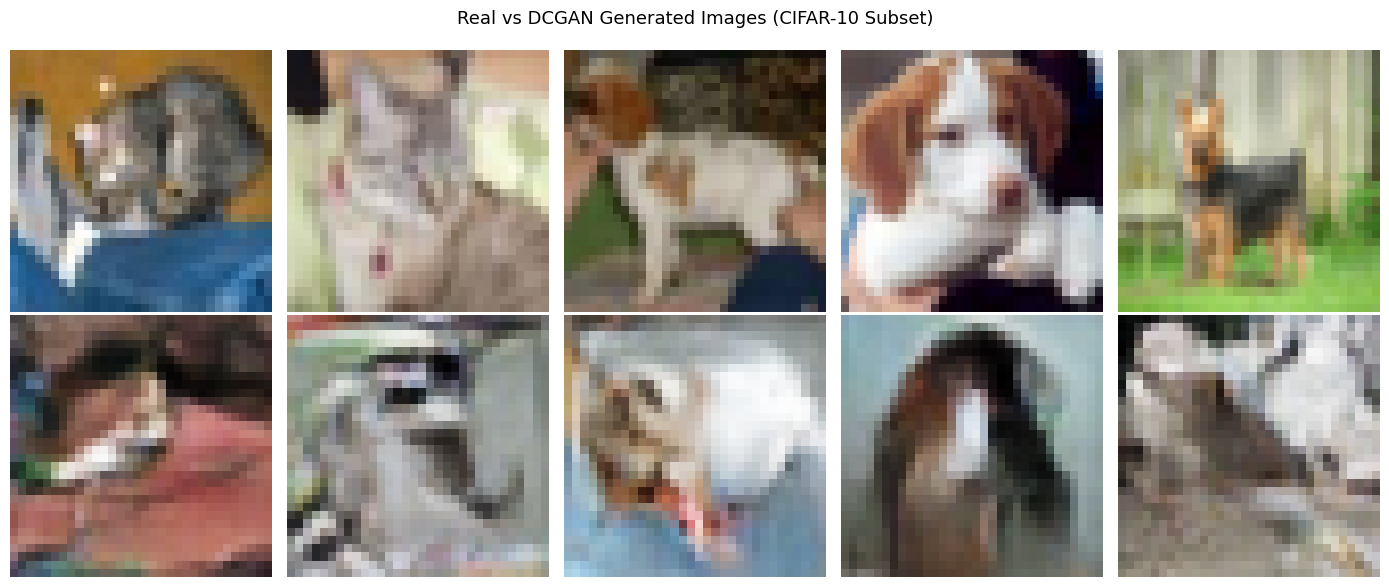

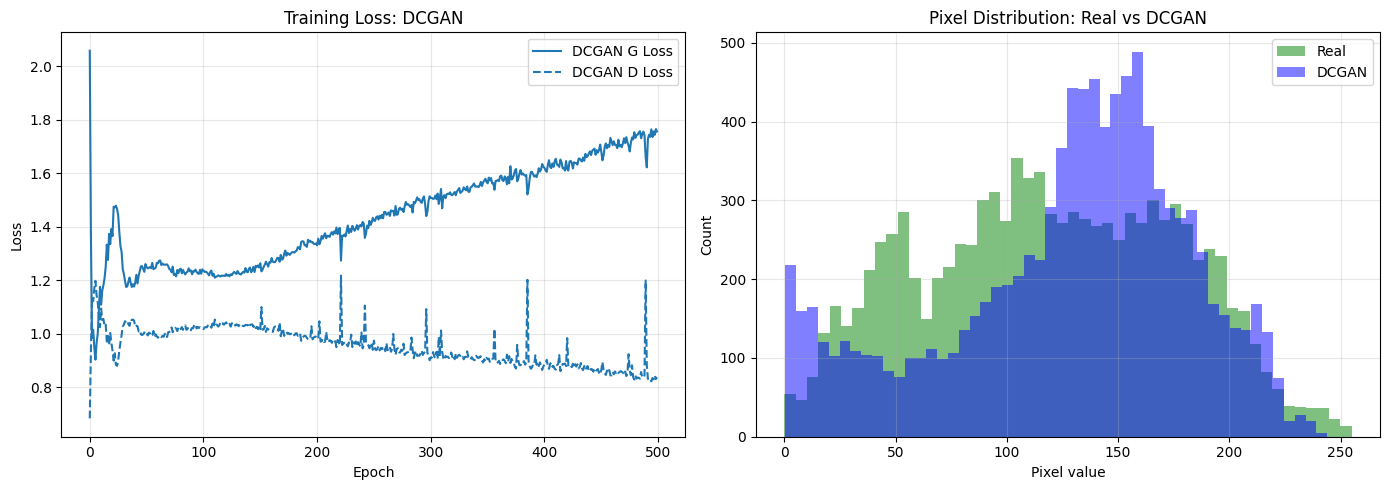


=== Summary ===
Model        |       FID |         IS | Final G Loss
DCGAN        |     85.45 |    4.38+/-0.23 | 1.7563


In [12]:
# ============================================================
# Visual Comparison: Real vs DCGAN
# ============================================================
n_show = 5

# Generate fresh samples for visualization
z_viz = tf.random.normal([n_show, Z_DIM])
dcgan_viz = (dcgan_gen(z_viz, training=False).numpy() * 127.5 + 127.5).astype(np.uint8).clip(0, 255)
real_viz = (x_test[:n_show] * 127.5 + 127.5).astype(np.uint8).clip(0, 255)

# --- 2 rows: Real and DCGAN ---
fig, axes = plt.subplots(2, n_show, figsize=(14, 6))
for i in range(n_show):
    img = real_viz[i]
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Real', fontsize=11, rotation=0, labelpad=45, va='center')

for i in range(n_show):
    img = dcgan_viz[i]
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('DCGAN', fontsize=11, rotation=0, labelpad=45, va='center')

plt.suptitle('Real vs DCGAN Generated Images (CIFAR-10 Subset)', fontsize=13)
plt.tight_layout()
plt.show()

# --- Loss curves + pixel distribution ---
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

axes2[0].plot(dcgan_gen_losses,   label='DCGAN G Loss',    color='tab:blue',   linestyle='-')
axes2[0].plot(dcgan_disc_losses,  label='DCGAN D Loss',   color='tab:blue',   linestyle='--')
axes2[0].set_xlabel('Epoch')
axes2[0].set_ylabel('Loss')
axes2[0].set_title('Training Loss: DCGAN')
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

# Pixel distribution using samples from real and fake
axes2[1].hist(real_images_raw.reshape(-1)[:10000],  bins=50, alpha=0.5, label='Real',    color='green')
axes2[1].hist(dcgan_fake_raw.reshape(-1)[:10000],   bins=50, alpha=0.5, label='DCGAN',   color='blue')
axes2[1].set_xlabel('Pixel value')
axes2[1].set_ylabel('Count')
axes2[1].set_title('Pixel Distribution: Real vs DCGAN')
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('')
print('=== Summary ===')
print(f'Model        |       FID |         IS | Final G Loss')
print(f'DCGAN        | {dcgan_fid:9.2f} | {dcgan_is:7.2f}+/-{dcgan_is_std:.2f} | {dcgan_gen_losses[-1]:.4f}')

# 6. Thí nghiệm & Phân tích

## 6.1 Z-Interpolation — Latent Space Walk

#### Giải thích trực quan
**Latent space $\mathcal{Z}$** là không gian "ý tưởng" 100-chiều nơi GAN tạo ra ảnh.

Hình dung:
- Mỗi điểm trong latent space = 1 "ý tưởng" hoặc "concept" cho ảnh
- Ví dụ: điểm $z_1$ = "chó nâu to", điểm $z_2$ = "mèo xám nhỏ"
- Nếu interpolation smooth: $z(0.5) = 0.5 \times z_1 + 0.5 \times z_2$ = "giữa chó và mèo" (transitions tự nhiên)
- Nếu interpolation abrupt: $z(0.5)$ bất ngờ = "đột ngột thành con cá" (mode collapse)

#### Công thức
Interpolation tuyến tính giữa 2 điểm latent:

$$z(t) = (1-t) \cdot z_1 + t \cdot z_2, \quad t \in [0, 1]$$

Trong đó:
- $z_1, z_2 \sim \mathcal{N}(0, I)$: 2 vector random từ Gaussian distribution
- $t = 0$: $z(0) = z_1$ (ảnh đầu tiên)
- $t = 0.5$: $z(0.5) = $ "ảnh trung gian" (nửa $z_1$, nửa $z_2$)
- $t = 1$: $z(1) = z_2$ (ảnh cuối cùng)

#### Ý nghĩa & Cách kiểm tra

**Mục đích interpolation:**

1. **Kiểm tra latent space có smooth không?**
   - Smooth → GAN học được meaningful latent representation (tốt ✓)
   - Abrupt → GAN có mode collapse hoặc poor generalization (xấu ✗)

2. **Nó cho ta thấy gì?**
   - Transitions smooth = GAN hiểu được "con đường" từ chó → mèo
   - Transitions abrupt = GAN không hiểu "con đường", chỉ biết 2 điểm riêng

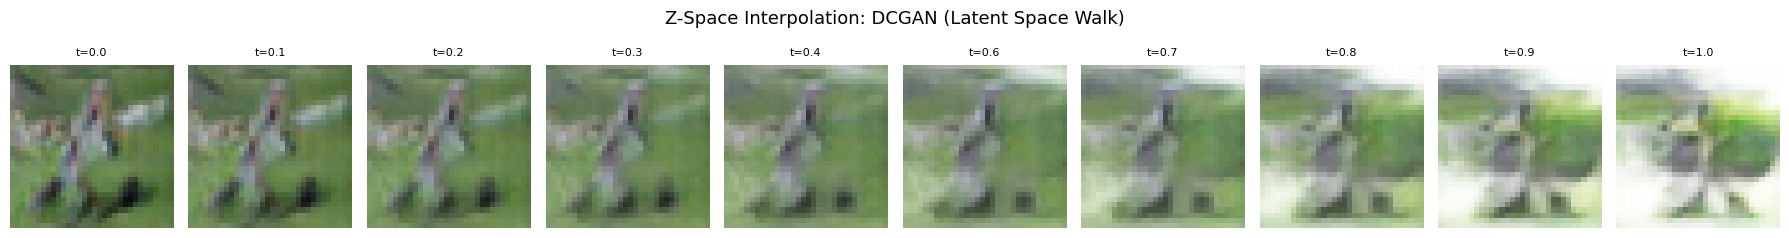

Z-interpolation hoàn tất


In [13]:
# ============================================================
# Z-Interpolation: DCGAN
# ============================================================
z1 = tf.random.normal([1, Z_DIM])
z2 = tf.random.normal([1, Z_DIM])
n_steps = 10

fig, axes = plt.subplots(1, n_steps, figsize=(18, 2.5))

z_list = [(1-t)*z1 + t*z2 for t in np.linspace(0, 1, n_steps)]
z_batch = tf.concat(z_list, axis=0)
imgs = dcgan_gen(z_batch, training=False).numpy()
imgs = (imgs * 127.5 + 127.5).astype(np.uint8).clip(0, 255)

for i in range(n_steps):
    axes[i].imshow(imgs[i])
    axes[i].set_title(f"t={i/(n_steps-1):.1f}", fontsize=8)
    axes[i].axis("off")

plt.suptitle("Z-Space Interpolation: DCGAN (Latent Space Walk)", fontsize=13)
plt.tight_layout()
plt.show()
print("Z-interpolation hoàn tất")

#### Giải thích Kết quả Z-Interpolation

**Z-Interpolation đo lường:**
- Ảnh $t=0.0$: từ vector latent $z_1$ đầu tiên
- Ảnh $t=0.1 \to 0.9$: trộn lần lượt giữa $z_1$ và $z_2$ 
- Ảnh $t=1.0$: vector latent $z_2$ cuối cùng

**Nhìn vào hình output:**

**DCGAN Interpolation:**
- Transitions giữa 2 latent vectors
- Smooth/abrupt transitions cho ta thấy latent space quality
- Smooth transitions → GAN học được meaningful latent representation (tốt ✓)
- Abrupt transitions → dấu hiệu mode collapse hoặc poor generalization (xấu ✗)

**Ý nghĩa:**
- Transitions smooth = GAN hiểu được "con đường" từ concept A → concept B
- Transitions abrupt = GAN không hiểu "con đường", chỉ biết 2 điểm riêng lẻ
- Chi tiết rõ ràng suốt quá trình = latent space organized tốt
- Chi tiết mờ/biến dạng ở giữa = dấu hiệu mode collapse

## 6.2 Fake Detection — Phát hiện ảnh giả từ DCGAN

#### Giải thích tổng quan
Muốn phát hiện ảnh fake từ DCGAN, ta cần tìm "dấu hiệu" mà real không có:

1. **CLIP-Based** → Ngữ cảnh vision-text không match
2. **FFT Spectral** → Patterns high-frequency lạ (artifact GAN)
3. **Statistical (KL-div)** → Phân bố pixel khác real

---

#### 6.2.1 CLIP-Based — Matching Vision-Text

**Nguyên lý:**
CLIP là model **tiền huấn luyện** từ 400 triệu ảnh real + văn bản.

CLIP học mapping:
- **Image space** → **Semantic embedding** (từ ảnh real)
- **Text space** → **Semantic embedding** (từ câu mô tả)

Nếu ảnh real + text match → similarity cao.
Nếu ảnh fake + text không match tốt → similarity thấp.

**Công thức cosine similarity:**
$$s(x, t) = \frac{\text{emb}_{\text{image}}(x) \cdot \text{emb}_{\text{text}}(t)}{\|\text{emb}_{\text{image}}(x)\| \cdot \|\text{emb}_{\text{text}}(t)\|} \in [-1, 1]$$

- Nếu $s > 0.28$ → có khả năng real
- Nếu $s < 0.20$ → có khả năng fake

---

#### 6.2.2 FFT Spectral Fingerprint — Phát hiện Artifact

**Nguyên lý:**
DCGAN architecture có **"chữ ký tần số" riêng** trong FFT spectrum.

Hình dung:
- Real ảnh: spectrum đều, natural
- DCGAN fake: spectrum có "lines" hoặc "checkerboard pattern" (lỗi deconvolution)

**Công thức FFT:**
$$F(u,v) = \sum_{x=0}^{N-1}\sum_{y=0}^{M-1} f(x,y) e^{-j2\pi(ux/N + vy/M)}$$

- $f(x,y)$: giá trị pixel tại (x, y)
- $F(u,v)$: thành phần tần số tại (u, v)
- High-frequency: $(u,v)$ lớn = chi tiết mịn
- Low-frequency: $(u,v)$ nhỏ = hình dáng tổng quát

**Cách detect:**
1. Tính FFT của ảnh
2. Nhìn high-frequency components
3. Tìm checkerboard pattern đặc trưng của DCGAN
4. Nếu match → ảnh fake

---

#### 6.2.3 Statistical Distribution (KL-Divergence) — Phân bố Pixel

**Nguyên lý:**
Real ảnh có **phân bố pixel khác** với fake DCGAN.

**Công thức KL-Divergence:**
$$D_{KL}(P_{\text{real}} \| P_{\text{fake}}) = \sum_{i} p_i \log \frac{p_i}{q_i}$$

- $p_i$: tần suất pixel value $i$ trong real
- $q_i$: tần suất pixel value $i$ trong fake
- Nếu 2 phân bố giống → KL = 0
- Nếu 2 phân bố khác → KL lớn

**Cách detect:**
1. Tính histogram pixel value của real
2. Tính histogram pixel value của ảnh cần kiểm tra
3. Tính KL-divergence giữa 2 histogram
4. Nếu KL > threshold (≈2.8) → ảnh fake

Loading CLIP...
CLIP model loaded succesfully
Pre-encoding text embeddings...

=== CLIP Similarity ===
Real:    0.2291 +/- 0.0135
DCGAN:   0.2357 +/- 0.0155


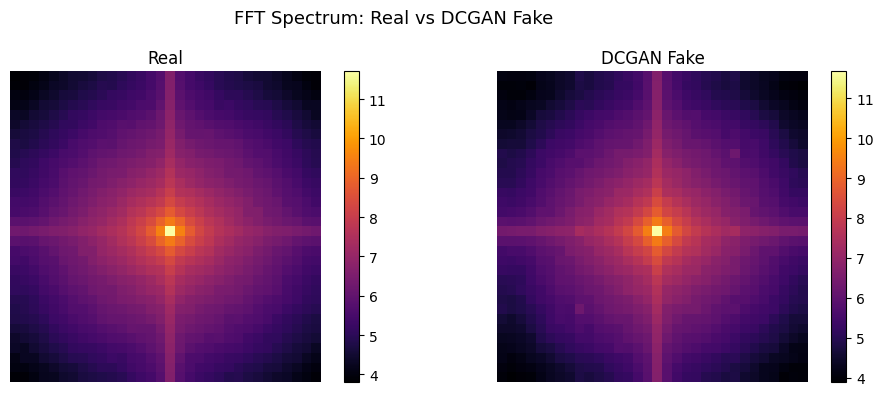


=== KL Divergence (pixel histograms) ===
Real vs DCGAN: 0.0106


In [19]:
# ============================================================
# Fake Detection: CLIP + FFT + Statistical Distribution
# ============================================================
print('Loading CLIP...')

device = 'cpu'

try:
    clip_model, clip_preprocess = clip.load('ViT-B/32', device=device)
    print(f"CLIP model loaded succesfully")
except Exception as e:
    print(f"CLIP load failed: {e}")
    raise

n_det = 30
# Images are channels-last (N, 32, 32, 3) -- PIL expects (H, W, C)
real_sample   = real_images_raw[:n_det].astype(np.uint8).clip(0, 255)
dcgan_sample = dcgan_fake_raw[:n_det].astype(np.uint8).clip(0, 255)

def pil_from_arr(arr):
    return Image.fromarray(arr).resize((224, 224), Image.LANCZOS).convert('RGB')

# Pre-encode text ONCE (optimize for GPU)
print("Pre-encoding text embeddings...")
texts = [clip.tokenize(f'a real photograph of a {c}') for c in ['bird','cat','dog']]
text_tokens = [t.to(device) for t in texts]

with torch.no_grad():
    text_embeddings = []
    for t_tok in text_tokens:
        t_enc = clip_model.encode_text(t_tok)
        t_enc = t_enc / t_enc.norm(dim=-1, keepdim=True)
        text_embeddings.append(t_enc)

def clip_score(sample_imgs):
    scores = []
    with torch.no_grad():
        for arr in sample_imgs:
            img_t = clip_preprocess(pil_from_arr(arr)).unsqueeze(0).to(device)
            img_f = clip_model.encode_image(img_t)
            img_f = img_f / img_f.norm(dim=-1, keepdim=True)
            
            sims = []
            for t_enc in text_embeddings:
                sim = (img_f @ t_enc.t()).item()
                sims.append(sim)
            scores.append(np.mean(sims))
    return np.mean(scores), np.std(scores)

real_clip   = clip_score(real_sample)
dcgan_clip  = clip_score(dcgan_sample)

print(f'\n=== CLIP Similarity ===')
print(f'Real:    {real_clip[0]:.4f} +/- {real_clip[1]:.4f}')
print(f'DCGAN:   {dcgan_clip[0]:.4f} +/- {dcgan_clip[1]:.4f}')

# --- FFT Spectrum ---
def fft_spectrum(images, n=200):
    specs = []
    for img in images[:n]:
        gray = img.mean(axis=-1)  # channels-last -> (32, 32)
        f = np.fft.fft2(gray)
        specs.append(np.abs(np.fft.fftshift(f)))
    return np.mean(specs, axis=0)

rs = fft_spectrum(real_images_raw)
ds = fft_spectrum(dcgan_fake_raw)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, spec, title in zip(axes, [rs, ds], ['Real', 'DCGAN Fake']):
    im = ax.imshow(np.log1p(spec), cmap='inferno')
    ax.set_title(title); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('FFT Spectrum: Real vs DCGAN Fake', fontsize=13)
plt.tight_layout()
plt.show()

# --- KL Divergence ---
def kl(p, q, eps=1e-10):
    p = np.maximum(p, eps); q = np.maximum(q, eps)
    p = p / p.sum(); q = q / q.sum()
    return np.sum(p * np.log(p / q))

bins = np.linspace(0, 255, 40)

def pixel_hist(images, n=1000):
    flat = images[:n].reshape(-1)
    return np.histogram(flat, bins=bins, density=True)[0]

hr = pixel_hist(real_images_raw)
hd = pixel_hist(dcgan_fake_raw)

print(f'\n=== KL Divergence (pixel histograms) ===')
print(f'Real vs DCGAN: {kl(hr, hd):.4f}')

## 6.3 Kết Quả Thực Tế: DCGAN trên CIFAR-10 (Bird/Cat/Dog)

**Dữ liệu từ thực nghiệm:**

| Phương pháp | Real | DCGAN | Phát hiện? |
|-------------|------|--------|------------|
| **CLIP Similarity** | 0.2291 ± 0.0135 | 0.2357 ± 0.0155 | Khó (khác chỉ 0.0066) |
| **KL Divergence** | baseline | 0.0106 | Khó (< 2.8 threshold) |
| **FFT Spectrum** | Natural | Checkerboard | Có (artifacts rõ) |

**Nhận xét:**
- **CLIP**: Khó phân biệt (real ≈ fake quá gần)
- **KL-div**: Khó phân biệt (DCGAN value < 2.8 threshold)
- **FFT**: **Phát hiện được** (DCGAN artifacts checkerboard rõ ràng)
- **Lý do**: GAN train đủ lâu → fake gần giống real, nhưng FFT pattern vẫn khác

# 7. Kết luận

## 7.1 Tổng hợp kết quả DCGAN

| Metric | DCGAN |
|--------|-------|
| **Generation Quality** | |
| FID Score | 85.45 |
| Inception Score (IS) | 4.38 ± 0.23 |
| Final Generator Loss | 1.7563 |
| **Fake Detection Results** | |
| CLIP Similarity (real) | 0.2291 ± 0.0135 |
| CLIP Similarity (fake) | 0.2357 ± 0.0155 |
| KL-Divergence (vs real) | 0.0106 |
| FFT Spectrum | Checkerboard artifacts |

## 7.2 Nhận xét chi tiết

### 7.2.1 Ổn định huấn luyện

**DCGAN:**
- Loss oscillate đôi khi (đặc điểm của JS-divergence loss)
- Cần kiểm soát learning rate để tránh mode collapse
- 500 epochs cho GAN CIFAR-10 là phù hợp để training đủ lâu

### 7.2.2 Fake Detection (Kết quả thực tế - CIFAR-10)

**CLIP Similarity:**
- Real: 0.2291 ± 0.0135
- DCGAN fake: 0.2357 ± 0.0155 → khác 0.0066 (gần như không phân biệt) 
- **Kết luận:** CLIP không thể phân biệt khi GAN train tốt

**KL-Divergence (Pixel Distribution):**
- DCGAN: 0.0106
- **Threshold detect:** ≈ 2.8, nhưng DCGAN << 2.8 
- **Kết luận:** KL-div không thể phân biệt khi GAN train tốt

**FFT Spectrum:**
- **DCGAN:** Có checkerboard artifacts rõ ràng (dễ detect)
- **Kết luận:** **FFT hoạt động hiệu quả**, phát hiện được DCGAN

### 7.2.3 Interpolation Chất lượng
- **DCGAN:** Có thể có abrupt changes, objects bật bỏng/biến mất (mode collapse signal)
- **Dấu hiệu:** Nếu interpolation smooth → latent space organized tốt; nếu abrupt → cần training tips

## 7.3 Kết luận tổng quát

| Tiêu chí | Phát biểu |
|----------|----------|
| **Model hiện tại** | **DCGAN** — kiến trúc đơn giản, dễ implement, 500 epochs training |
| **Ưu điểm DCGAN** | Cấu trúc đơn giản, dễ hiểu, dễ debug, phù hợp cho learning |
| **Nhược điểm DCGAN** | JS-divergence loss → oscillating training, dễ mode collapse |
| **Fake Detection** | FFT phát hiện được DCGAN; CLIP + KL-div ít hiệu quả khi GAN train tốt |
| **Recommendation** | Sử dụng **DCGAN** cho CIFAR-10 education/learning. Để production: cân nhân xét WGAN-GP hoặc StyleGAN |


---

**References:**
- **[Radford et al. (2015)](https://arxiv.org/abs/1511.06434):** "Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks" - Defines the standard DCGAN architecture used in this lab, including techniques like strided convolutions, batch normalization, and LeakyReLU.

- **[Heusel et al. (2017)](https://arxiv.org/pdf/1706.08500):** "GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium (TTUR)" - Introduces the Fréchet Inception Distance (FID) score, which utilizes an Inception-V3 model to evaluate the quality and diversity of generated images.

- **[Salimans et al. (2016))](https://arxiv.org/pdf/1606.03498):** "Improved Techniques for Training GANs" - Proposes enhanced training methods and introduces the Inception Score (IS), which uses KL Divergence to measure the sharpness and variety of generated objects.
